# Vorlage Plausi-Tests
## Ausländische Bevölkerung nach Jahr und Nationalität (historische Daten)
### Kurzbeschreibung
Anzahl Personen der ausländischen Wohnbevölkerung nach Jahr, Nationalität (ausgewählte Nationalitäten).

Datum: 29.01.2026


Dataset auf PROD-Datakatalog: Link https://data.stadt-zuerich.ch/dataset/bev_bestand_nationen_hist_jahr_od3482

Dataset auf INTEG-Datakatalog: Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_hist_jahr_od3482


### Importiere die notwendigen Packages

In [91]:
#%pip install geopandas altair fiona requests folium mplleaflet contextily seaborn datetime plotly leafmap

In [92]:
import altair as alt
import datetime
import folium 
import geopandas as gpd
import io
from IPython.display import Markdown as md
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import pivottablejs
#from pivottablejs import pivot_ui
import plotly.express as px
import requests
import seaborn as sns

Welche Python, Altair und Seaborn Version wird verwendet?

In [93]:
#base env 2025: Python 3.11.7
import ipykernel
print(ipykernel.__version__)

import sys
import platform
print("Python-Version:", sys.version)
print("Python-Implementierung:", platform.python_implementation())
print("Python-Build:", platform.python_build())
print("Python-Compiler:", platform.python_compiler())

print("Altair-Version:", alt.__version__)
print("Seaborn-Version:", sns.__version__)

6.29.3
Python-Version: 3.11.8 | packaged by Anaconda, Inc. | (main, Feb 26 2024, 21:34:05) [MSC v.1916 64 bit (AMD64)]
Python-Implementierung: CPython
Python-Build: ('main', 'Feb 26 2024 21:34:05')
Python-Compiler: MSC v.1916 64 bit (AMD64)
Altair-Version: 5.0.1
Seaborn-Version: 0.12.2


Importiere die eigenen Funktionen, die unter ../0_scripts abegelegt sind:

In [94]:
import sys
sys.path.append('../0_scripts')

import my_py_dataviz_functions as mypy_dv
import my_py_dataloading_functions as mypy_dl

In [95]:
SSL_VERIFY = False
# evtl. SSL_VERIFY auf False setzen wenn die Verbindung zu https://www.gemeinderat-zuerich.ch nicht klappt (z.B. wegen Proxy)
# Um die SSL Verifikation auszustellen, bitte die nächste Zeile einkommentieren ("#" entfernen)
# SSL_VERIFY = False

In [96]:
if not SSL_VERIFY:
    import urllib3
    urllib3.disable_warnings()

### Settings
Definiere Settings. 
Hier das Zahlenformat von Float-Werten (z.B. *'{:,.2f}'.format* mit Komma als Tausenderzeichen)

In [97]:
#pd.options.display.float_format = lambda x : '{:,.1f}'.format(x) if (np.isnan(x) | np.isinf(x)) else '{:,.0f}'.format(x) if int(x) == x else '{:,.1f}'.format(x)
pd.options.display.float_format = '{:.0f}'.format
pd.set_option('display.width', 100)
pd.set_option('display.max_columns', 15)

#### Paletten aus Zuericolors
Die Farbwerte habe ich aus R ausgelesen. Siehe dazu: `G:\sszsim\myR\zuericolors4python`

In [98]:
# Quantitative Paletten
zuericolors_qual12 = ["#3431DE", "#0A8DF6", "#23C3F1", "#7B4FB7", "#DB247D", "#FB737E", "#007C78", "#1F9E31", "#99C32E", "#9A5B01", "#FF720C", "#FBB900"]
zuericolors_qual12br = ["#5D4BFE", "#4AA9FF", "#55FFFF", "#986AD5", "#FC4C99", "#FF919A", "#349894", "#44B14A", "#B7E14E", "#B97624", "#FF7231", "#FFD736"]
zuericolors_qual12da= ["#0017BF", "#0072D7", "#00A5D2", "#5E359A", "#BA0062", "#DA5563", "#00615D", "#00770F", "#7BA600", "#7B4100", "#DC5500", "#DA9C00"]
# Divergente Paletten
zuericolors_div9val  =  ["#A30059", "#DB247D", "#FF579E", "#FFA8D0", "#E4E0DF", "#A8DBB1", "#55BC5D", "#1F9E31", "#10652A"] 
zuericolors_div9ntr  =  ["#782600", "#CC4309", "#FF720C", "#FFBC88", "#E4E0DF", "#AECBFF", "#6B8EFF", "#3B51FF", "#2F2ABB"] 
# Geschlechter Paletten
zuericolors_gender3  =  ["#349894", "#FFD736", "#986AD5"] 
zuericolors_gender6origin  =  ["#00615D", "#349894", "#DA9C00", "#FFD736", "#5E359A", "#986AD5"] 
zuericolors_gender5wedding  =  ["#349894", "#FFD736", "#3431DE", "#B8B8B8", "#D6D6D6"] 
# Sequenzielle Paletten
zuericolors_seq9blu  =  ["#CADEFF", "#AEC2FF", "#93A6FF", "#778AFF", "#5B6EFF", "#4D59E2", "#3E44C5", "#302FA7", "#211A8A"] 
zuericolors_seq9red  =  ["#FED2EE", "#FEAED6", "#F589BE", "#F165A5", "#ED408D", "#D1307B", "#B52069", "#991056", "#7D0044"] 
zuericolors_seq9grn  =  ["#CFEED8", "#A8E0B3", "#81D18F", "#5BC36A", "#34B446", "#2A9A3C", "#208032", "#166529", "#0C4B1F"] 
zuericolors_seq9brn  =  ["#FCDDBB", "#F7BD8C", "#F39D5E", "#EE7D2F", "#EA5D00", "#C84E00", "#A53E00", "#832F00", "#611F00"]

#### Zeitvariabeln


In [99]:
#Zeitvariabeln als Strings:
now = datetime.date.today()
year_today = now.strftime("%Y")
date_today = "_"+now.strftime("%Y-%m-%d")

#Zeitvariabeln als Integers:
int_times = now.timetuple()
aktuellesJahr = int_times[0]
aktuellerMonat = int_times[1]
selectedMonat = int_times[1]-2
#print(aktuellesJahr, aktuellerMonat,'datenstand: ', selectedMonat, int_times)

### Daten importieren und Metadaten checken

- status: int / prod
- data_source: web / ld / dropzone
- datums_attr: beschreibt das oder die Datumsfelder, die als Datum geparsed werden sollen. Falls es keines gibt: None

In [100]:
package_name = "bev_bestand_nationen_hist_jahr_od3482"

In [101]:
data2betested = mypy_dl.load_data(
    status = 'int'
    , data_source = 'web'
    , package_name = package_name
    , dataset_name = "BEV348OD3482"    
    , datums_attr = ['StichtagDatJahr']
    )

fp lautet:https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_hist_jahr_od3482/download/BEV348OD3482.csv


 **Überprüfe die Metadaten:**

 **Dataset auf INTEG-Datakatalog:** Link https://data.integ.stadt-zuerich.ch/dataset/int_dwh_bev_bestand_nationen_hist_jahr_od3482 

 **Dataset auf PROD-Datakatalog:** Link https://data.stadt-zuerich.ch/dataset/bev_bestand_nationen_hist_jahr_od3482 

data_source: web


In [102]:
data2betested.head(2).T

,0,1
StichtagDatJahr,1894-01-01 00:00:00,1900-01-01 00:00:00
NationHistCd,8207,8207
NationHistLang,Deutschland,Deutschland
AnzBestWir,23159,31122


Berechne weitere Attribute falls notwendig

In [103]:
data2betested = (
    data2betested
    .copy()
    .assign(
        #Aktualisierungs_Datum_str= lambda x: x.Aktualisierungs_Datum.astype(str),
        StichtagDatJahr_str = lambda x: x.StichtagDatJahr.astype(str),
        Jahr = lambda x: x.StichtagDatJahr,
        Jahr_end = lambda x: x.StichtagDatJahr+pd.offsets.YearEnd(0),
        Jahr_nbr = lambda x: x.Jahr.dt.year,
    )
    .sort_values('StichtagDatJahr', ascending=False)
    )
data2betested.dtypes

StichtagDatJahr        datetime64[ns]
NationHistCd                    int64
NationHistLang                 object
AnzBestWir                      int64
StichtagDatJahr_str            object
Jahr                   datetime64[ns]
Jahr_end               datetime64[ns]
Jahr_nbr                        int32
dtype: object

Minimales und maximales Jahr im Datensatz

In [104]:
data_max_jahr = str(max(data2betested.Jahr).year)
data_min_jahr = str(min(data2betested.Jahr).year)

print(f"Die Daten haben ein Minimumjahr von {data_min_jahr} und ein Maximumjahr von {data_max_jahr}")

Die Daten haben ein Minimumjahr von 1894 und ein Maximumjahr von 2024


In [105]:
data_max_date = max(data2betested.Jahr_end).strftime('%Y-%m-%d')
data_min_date = min(data2betested.Jahr_end).strftime('%Y-%m-%d')


print(f"Die Daten haben ein Minimumjahr von {data_min_date} und ein Maximumjahr von {data_max_date}")

Die Daten haben ein Minimumjahr von 1894-12-31 und ein Maximumjahr von 2024-12-31


### Einfache Datentests

In [106]:
data2betested.info(memory_usage='deep', verbose=True)

<class 'pandas.core.frame.DataFrame'>
Index: 964 entries, 109 to 0
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   StichtagDatJahr      964 non-null    datetime64[ns]
 1   NationHistCd         964 non-null    int64         
 2   NationHistLang       964 non-null    object        
 3   AnzBestWir           964 non-null    int64         
 4   StichtagDatJahr_str  964 non-null    object        
 5   Jahr                 964 non-null    datetime64[ns]
 6   Jahr_end             964 non-null    datetime64[ns]
 7   Jahr_nbr             964 non-null    int32         
dtypes: datetime64[ns](3), int32(1), int64(2), object(2)
memory usage: 178.0 KB


In [107]:
print(f'The dataset has {data2betested.shape[0]:,.0f} rows (observations) and {data2betested.shape[1]:,.0f} columns (variables).')
print(f'There seem to be {data2betested.duplicated().sum()} exact duplicates in the data.')

The dataset has 964 rows (observations) and 8 columns (variables).
There seem to be 0 exact duplicates in the data.


Beschreibe einzelne Attribute

In [108]:
data2betested.describe()

,StichtagDatJahr,NationHistCd,AnzBestWir,Jahr,Jahr_end,Jahr_nbr
count,964,964,964,964,964,964
mean,1985-12-03 20:54:46.307053952,8221,5618,1985-12-03 20:54:46.307053952,1986-12-03 02:53:16.680497920,1986
min,1894-01-01 00:00:00,8204,2,1894-01-01 00:00:00,1894-12-31 00:00:00,1894
25%,1970-01-01 00:00:00,8212,343,1970-01-01 00:00:00,1970-12-31 00:00:00,1970
50%,2000-01-01 00:00:00,8222,1552,2000-01-01 00:00:00,2000-12-31 00:00:00,2000
75%,2012-01-01 00:00:00,8231,7032,2012-01-01 00:00:00,2012-12-31 00:00:00,2012
max,2024-01-01 00:00:00,8240,42554,2024-01-01 00:00:00,2024-12-31 00:00:00,2024
std,NaN,11,8598,NaN,NaN,37


Welches sind die Quartiere ohne Werte bei BEW?

In [109]:
data2betested[np.isnan(data2betested.AnzBestWir)]

,StichtagDatJahr,NationHistCd,NationHistLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr


### Verwende das Datum als Index

While we did already parse the `datetime` column into the respective datetime type, it currently is just a regular column. 
**To enable quick and convenient queries and aggregations, we need to turn it into the index of the DataFrame**

In [110]:
data2betested = data2betested.set_index("StichtagDatJahr")
data2betested = data2betested.sort_index()

In [111]:
data2betested.index.year.unique()

Index([1894, 1900, 1901, 1902, 1903, 1904, 1905, 1906, 1907, 1908,
       ...
       2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024],
      dtype='int32', name='StichtagDatJahr', length=111)

### Beschreibe einzelne Attribute

Beschreibe nicht numerische Attribute

In [112]:
# describe non-numerical features
try:
    with pd.option_context('display.float_format', '{:,.2f}'.format):
        display(data2betested.describe(exclude='number')) #,datetime_is_numeric=True
except:
    print("No categorical data in dataset.")

,NationHistLang,StichtagDatJahr_str,Jahr,Jahr_end
count,964,964,964,964
unique,21,111,NaN,NaN
top,Deutschland,1930-01-01,NaN,NaN
freq,110,21,NaN,NaN
mean,NaN,NaN,1985-12-03 20:54:46.307053952,1986-12-03 02:53:16.680497920
min,NaN,NaN,1894-01-01 00:00:00,1894-12-31 00:00:00
25%,NaN,NaN,1970-01-01 00:00:00,1970-12-31 00:00:00
50%,NaN,NaN,2000-01-01 00:00:00,2000-12-31 00:00:00
75%,NaN,NaN,2012-01-01 00:00:00,2012-12-31 00:00:00
max,NaN,NaN,2024-01-01 00:00:00,2024-12-31 00:00:00


Beschreibe numerische Attribute

In [113]:
# describe numerical features
try:
    with pd.option_context('display.float_format', '{:,.0f}'.format):
        display(data2betested.describe(include='number'))
except:
    print("No numercial data in dataset.")

,NationHistCd,AnzBestWir,Jahr_nbr
count,964,964,964
mean,"8,221","5,618","1,986"
std,11,"8,598",37
min,"8,204",2,"1,894"
25%,"8,212",343,"1,970"
50%,"8,222","1,552","2,000"
75%,"8,231","7,032","2,012"
max,"8,240","42,554","2,024"


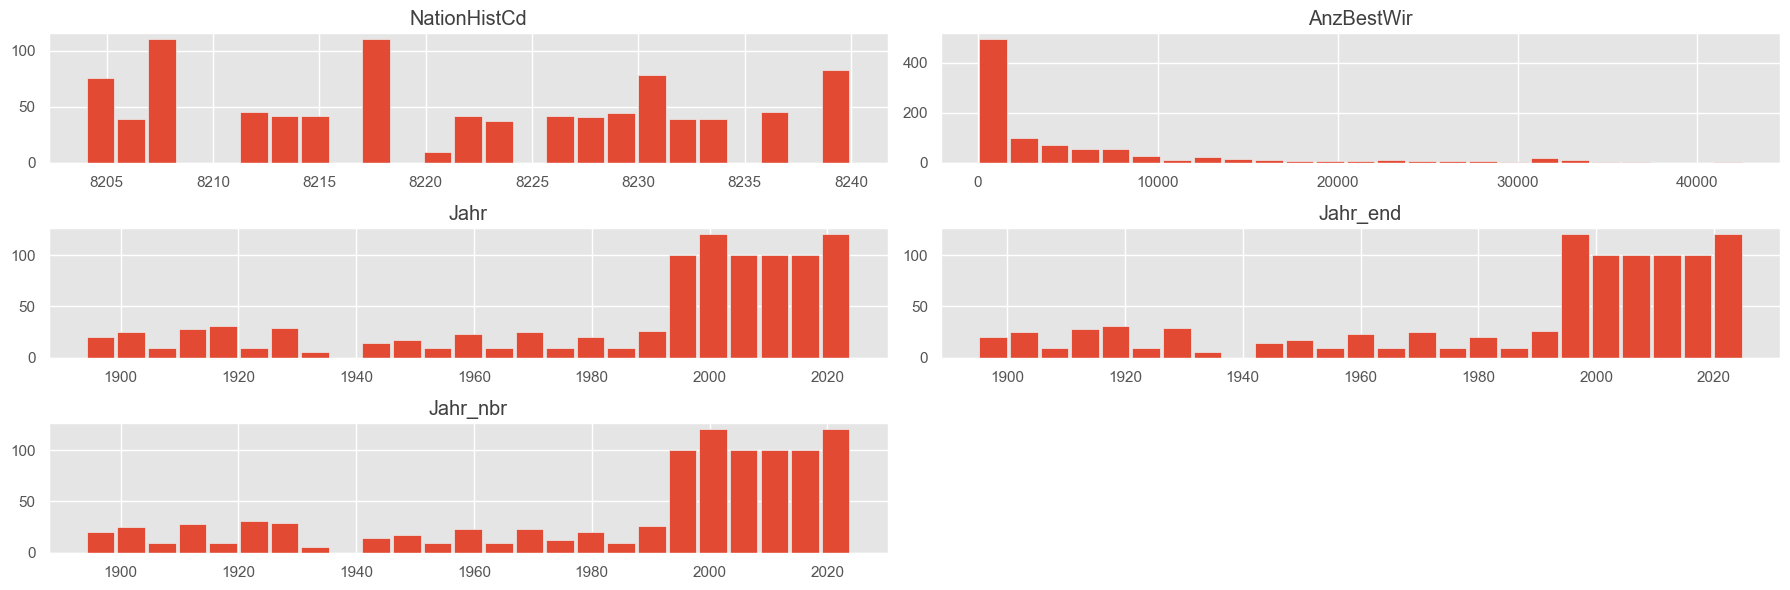

In [114]:
plt.style.use('ggplot')
params = {
    'text.color': (0.25, 0.25, 0.25),
    'figure.figsize': [18, 6],
   }
plt.rcParams.update(params)

try:
    data2betested.hist(bins=25, rwidth=0.9)
    plt.tight_layout()
    plt.show()
except:
    print("No numercial data to plot.") 

### Gibt es Duplikate?

In [115]:
# find duplicate rows
duplicate_rows = data2betested[data2betested.duplicated()]
duplicate_rows

,NationHistCd,NationHistLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,


### Nullwerte und Missings?

In [116]:
data2betested.isnull().sum()

NationHistCd           0
NationHistLang         0
AnzBestWir             0
StichtagDatJahr_str    0
Jahr                   0
Jahr_end               0
Jahr_nbr               0
dtype: int64

In [117]:
# check missing values with missingno
# https://github.com/ResidentMario/missingno
#import missingno as msno
#msno.matrix(data2betested, labels=True, sort='descending');
#msno.heatmap(data2betested)

### Gruppierungen

In [118]:
agg_jahr = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['Jahr', 'Jahr_nbr', 'Jahr_end']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('Jahr', ascending=False) 
agg_jahr.reset_index().head(3)

,Jahr,Jahr_nbr,Jahr_end,sum_AnzBestWir
0,2024-01-01,2024,2024-12-31,100166
1,2023-01-01,2023,2023-12-31,99210
2,2022-01-01,2022,2022-12-31,97176


In [119]:
agg_nation = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['NationHistCd', 'NationHistLang']) \
    .agg(sum_AnzBestWir=('AnzBestWir', 'sum')) \
    .sort_values('NationHistCd', ascending=False) 
agg_nation.reset_index().head(3)

,NationHistCd,NationHistLang,sum_AnzBestWir
0,8240,Ungarn,35379
1,8239,Türkei,156957
2,8236,Spanien,251937


### Pivotiere

In [120]:
pivoted_df = data2betested.pivot_table(
    index='Jahr_nbr',
    columns= ('NationHistCd', 'NationHistLang'),
    values='AnzBestWir',
    aggfunc='sum'
)

# Sortieren nach der Aggregation 
#pivoted_df = pivoted_df.sort_values(by=pivoted_df.index[-1], axis=1, ascending=False)

# Sortieren der Zeilen (Jahre) in absteigender Reihenfolge
pivoted_df = pivoted_df.sort_index(ascending=False)

# Anzeigen des Ergebnisses
print(pivoted_df.head(8).T)

Jahr_nbr                      2024  2023  2022  2021  2020  2019  2018  2017
NationHistCd NationHistLang                                                 
8204         Belgien          1019   921   879   846   796   740   708   649
8205         Bulgarien         940   929   875   819   778   743   688   663
8206         Dänemark          453   460   469   421   405   422   406   411
8207         Deutschland     32091 32155 31916 31813 32648 33268 33579 33788
8212         Frankreich       5826  5773  5651  5313  5058  4910  4682  4458
8214         Griechenland     3700  3567  3365  3156  2988  2858  2718  2532
8215         Grossbritannien  3052  3241  3424  3623  3895  3774  3662  3584
8218         Italien         17492 17138 16614 15930 15589 15506 15080 14764
8220         Jugoslawien       NaN   NaN   NaN   NaN   NaN   NaN   NaN   NaN
8222         Liechtenstein     409   415   421   426   403   392   388   394
8223         Luxemburg         450   441   433   396   367   377   376   383

### Visualisierungen nach Zeitausschnitten

#### Entwicklung der ausländischen Wohnbevölkerung nach Nationalität

In [121]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAgg1 = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'NationHistCd', 'NationHistLang']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAgg1.reset_index().head(3)

,StichtagDatJahr,NationHistCd,NationHistLang,sum_WBev
0,1900-01-01,8204,Belgien,42
1,1900-01-01,8240,Ungarn,337
2,1900-01-01,8236,Spanien,102


In [122]:
#help(mypy_dv.plot_altair_multiline_highlight)

In [123]:
grafik1 = mypy_dv.plot_altair_multiline_highlight(
    data = myAgg1.reset_index().sort_values('NationHistCd', ascending=True)
    ,x = 'StichtagDatJahr:T'
    ,y = 'sum_WBev:Q'
    ,x_beschriftung = 'Jahr'
    , y_beschriftung = 'Anz. Personen'
    ,category = "NationHistLang:N"
    ,category_beschriftung= 'Legende:'
    ,x_sort = None
    ,palette_scheme = None # 'turbo','viridis','category20b','category20c', 'tableau20', 'sinebow', 'rainbow, 'dark2', 'inferno',
    ,custom_palette = zuericolors_qual12+zuericolors_gender6origin
    ,line_width = 1.1                 
    ,warning_status = "ignore" #always or ignore
    ,myTitle="Entwicklung der ausländischen Wohnbevölkerung nach Nationalität, seit "+str(int(data2betested.index.year.min()))
)
grafik1

alt.LayerChart(...)

#### Barcharts mit Seaborn

In [125]:
#myAgg = data2betested.loc["2008-11-30":"2021-10-31"]
myAggBar = data2betested.loc[data_min_date:data_max_date]\
    .groupby(['StichtagDatJahr', 'NationHistCd', 'NationHistLang', 'Jahr', 'Jahr_end', 'Jahr_nbr']) \
    .agg(sum_WBev=('AnzBestWir', 'sum')) \
    .sort_values('StichtagDatJahr', ascending=True) 

myAggBar.reset_index().head(3)

,StichtagDatJahr,NationHistCd,NationHistLang,Jahr,Jahr_end,Jahr_nbr,sum_WBev
0,1900-01-01,8204,Belgien,1900-01-01,1900-12-31,1900,42
1,1900-01-01,8240,Ungarn,1900-01-01,1900-12-31,1900,337
2,1900-01-01,8236,Spanien,1900-01-01,1900-12-31,1900,102


In [126]:
#help(sns.catplot)   

# #Stile for the following sns graphs
sns.set_theme(style="whitegrid")

##### Stacked Bar Chart

In [127]:
myAggBar.reset_index().head(2)

,StichtagDatJahr,NationHistCd,NationHistLang,Jahr,Jahr_end,Jahr_nbr,sum_WBev
0,1900-01-01,8204,Belgien,1900-01-01,1900-12-31,1900,42
1,1900-01-01,8240,Ungarn,1900-01-01,1900-12-31,1900,337


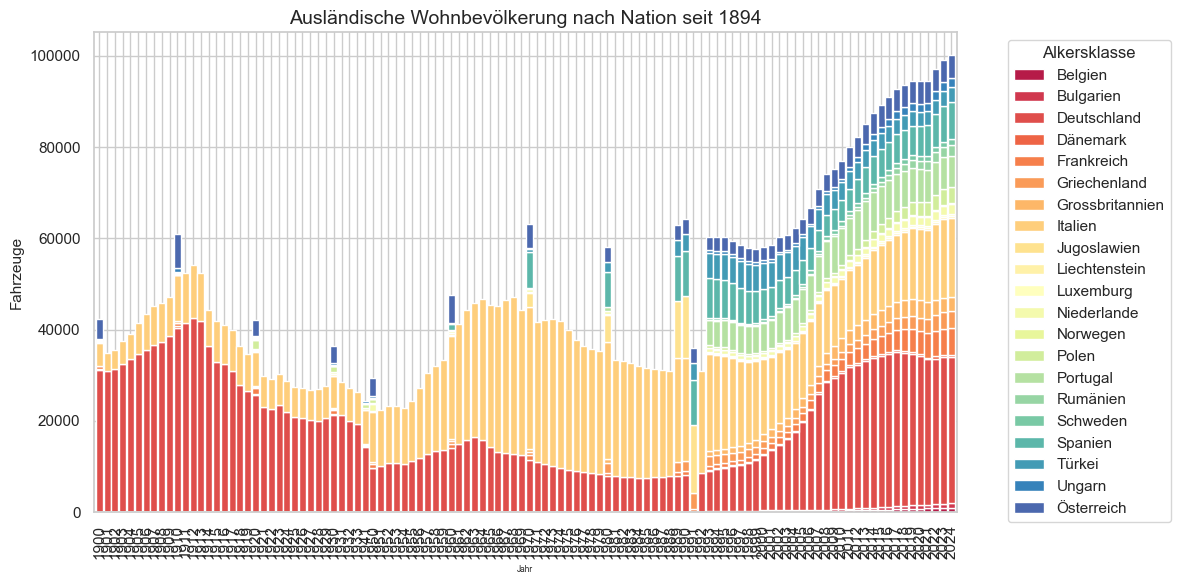

In [ ]:
# Daten vorbereiten

data = myAggBar.query("sum_WBev > 0").reset_index()
data_pivoted = data.pivot(index='Jahr_nbr', columns='NationHistLang', values='sum_WBev').fillna(0)

# Farbpalette erstellen
colors = sns.color_palette("Spectral", n_colors=len(data_pivoted.columns)) #"flare" / "vlag" / "icefire" / "Spectral", "cubehelix"
# Figur und Achsen erstellen
fig, ax = plt.subplots(figsize=(12, 6))
# Gestapeltes Balkendiagramm zeichnen
data_pivoted.plot(
    kind='bar', 
    stacked=True, 
    ax=ax, 
    color=colors,
    width=0.9
    )
# Titel hinzufügen
plt.title('Ausländische Wohnbevölkerung nach Nation seit ' + str(int(data2betested.index.year.min())), fontsize=14)
# Achsenbeschriftungen anpassen
ax.set_xlabel('Jahr', fontsize=11)
ax.set_ylabel('Fahrzeuge', fontsize=11)

# Legende anpassen
plt.legend(title='Alkersklasse', bbox_to_anchor=(1.05, 1), loc='upper left')
# Layout anpassen
plt.tight_layout()
# Diagramm anzeigen
plt.show()

In [129]:
data2betested.columns

Index(['NationHistCd', 'NationHistLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end',
       'Jahr_nbr'],
      dtype='object')

#### Faced Grids

In [130]:
myFG = data2betested.sort_values('NationHistCd', ascending=True) 
myFG

,NationHistCd,NationHistLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
StichtagDatJahr,,,,,,,
2003-01-01,8204,Belgien,206,2003-01-01,2003-01-01,2003-12-31,2003
1996-01-01,8204,Belgien,135,1996-01-01,1996-01-01,1996-12-31,1996
2017-01-01,8204,Belgien,649,2017-01-01,2017-01-01,2017-12-31,2017
1997-01-01,8204,Belgien,148,1997-01-01,1997-01-01,1997-12-31,1997
2016-01-01,8204,Belgien,594,2016-01-01,2016-01-01,2016-12-31,2016
...,...,...,...,...,...,...,...
2023-01-01,8240,Ungarn,1901,2023-01-01,2023-01-01,2023-12-31,2023
2009-01-01,8240,Ungarn,642,2009-01-01,2009-01-01,2009-12-31,2009
2005-01-01,8240,Ungarn,515,2005-01-01,2005-01-01,2005-12-31,2005


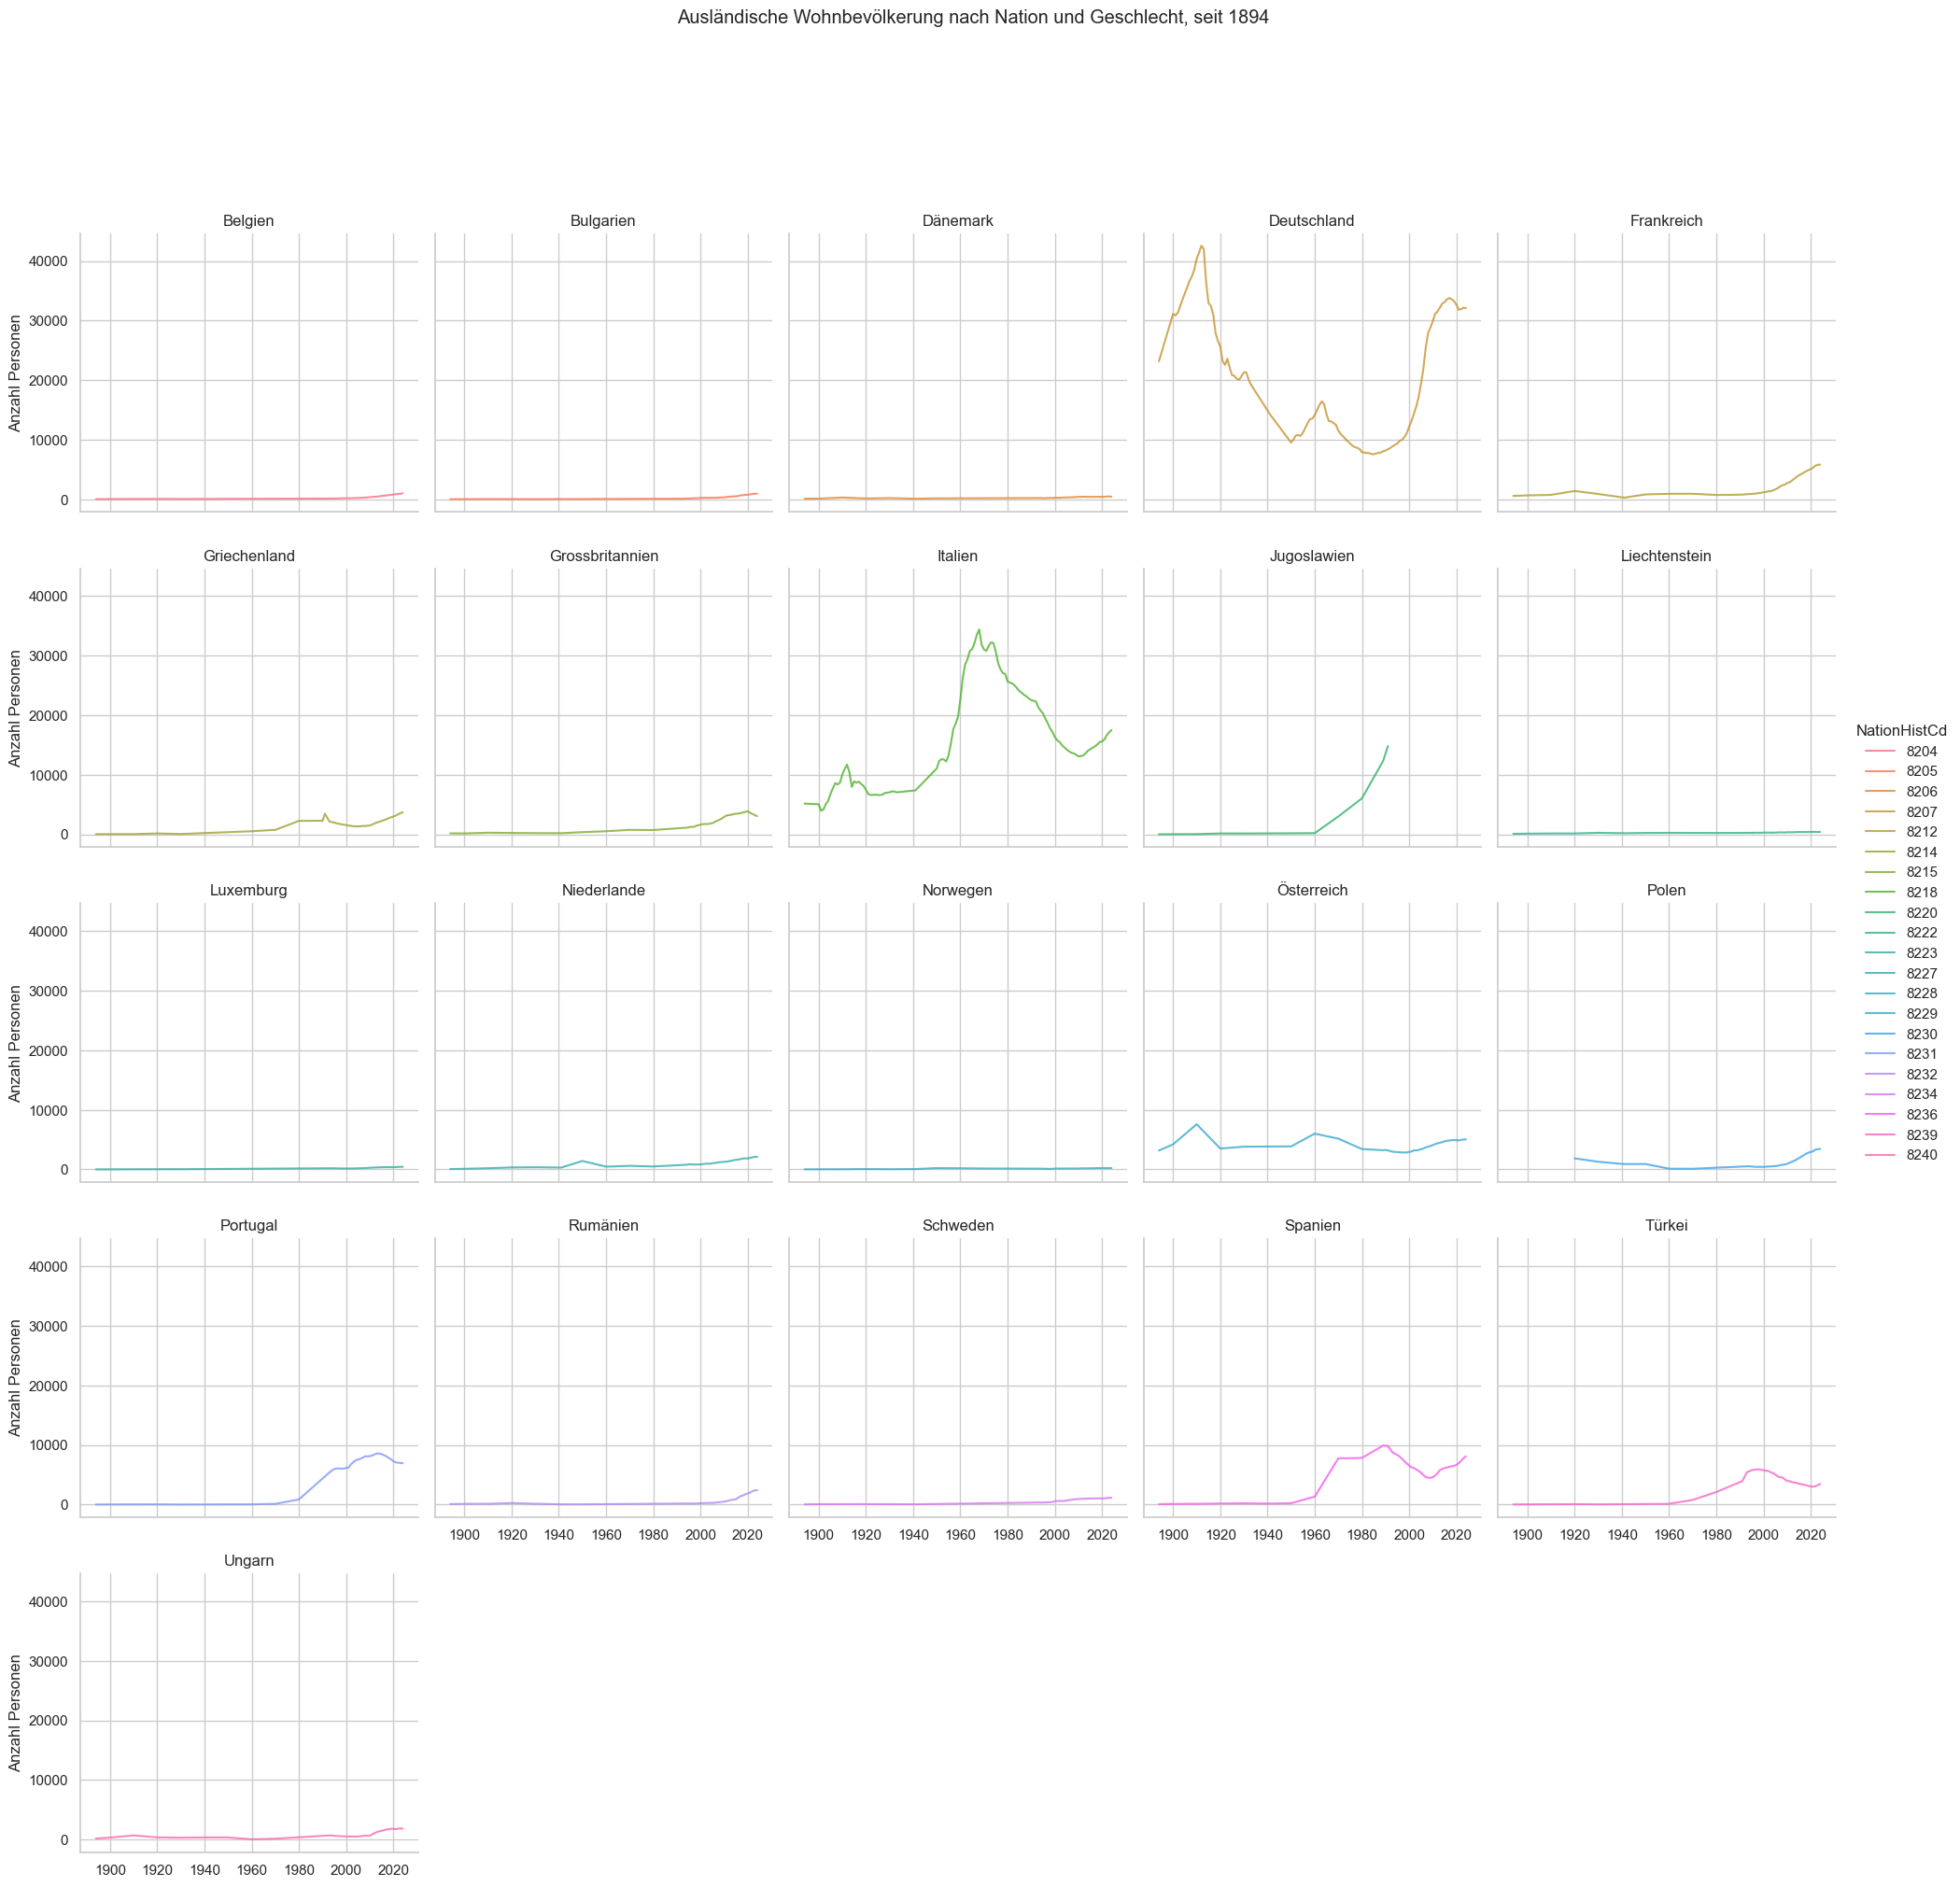

In [133]:
faced_grid1 = mypy_dv.plot_sns_facetgrid(
    data = myFG.reset_index().sort_values('NationHistCd', ascending=True)
    ,col = "NationHistLang"
    ,hue = "NationHistCd" 
    ,col_wrap = 5
    ,grafiktyp = sns.lineplot
    ,x = "StichtagDatJahr"
    ,y = "AnzBestWir"
    ,ylabel= "Anzahl Personen"
    ,warning_status ="ignore"
    ,height = 3
    ,myTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, seit "+str(int(data2betested.index.year.min()))
)
faced_grid1

#### Treemaps

**Funktion zum einfärben**

Muss ich noch als Funktion umsetzen 

In [134]:
# Extrahiere die Top-Fahrzeugmarken
zuzugsgebiet = data2betested['NationHistLang'].unique().tolist()
# Verfügbare Farben
verfügbare_farben_zuericolors = zuericolors_qual12 + zuericolors_qual12da + zuericolors_qual12br +  zuericolors_div9ntr

# Erstelle das Farben-Dictionary
farben_dict_zc = {'(?)':'lightgrey'}
for index, x in enumerate(zuzugsgebiet):
    farben_dict_zc[x] = verfügbare_farben_zuericolors[index % len(verfügbare_farben_zuericolors)]

# Das resultierende Farben-Dictionary
print(farben_dict_zc)
#print(verfügbare_farben_zuericolors)

{'(?)': 'lightgrey', 'Deutschland': '#3431DE', 'Schweden': '#0A8DF6', 'Dänemark': '#23C3F1', 'Norwegen': '#7B4FB7', 'Grossbritannien': '#DB247D', 'Bulgarien': '#FB737E', 'Türkei': '#007C78', 'Niederlande': '#1F9E31', 'Griechenland': '#99C32E', 'Jugoslawien': '#9A5B01', 'Spanien': '#FF720C', 'Liechtenstein': '#FBB900', 'Ungarn': '#0017BF', 'Portugal': '#0072D7', 'Belgien': '#00A5D2', 'Italien': '#5E359A', 'Luxemburg': '#BA0062', 'Österreich': '#DA5563', 'Rumänien': '#00615D', 'Frankreich': '#00770F', 'Polen': '#7BA600'}


##### Ausländische Wohnbevölkerung nach Nation und Geschlecht

In [135]:
#myTM = data2betested.loc[data_max_jahr].reset_index() \
myTM = data2betested.loc[(data2betested.index.year == 1910)|(data2betested.index.year == 2024)].reset_index()
myTM.reset_index().head(2)

,index,StichtagDatJahr,NationHistCd,NationHistLang,AnzBestWir,StichtagDatJahr_str,Jahr,Jahr_end,Jahr_nbr
0,0,1910-01-01,8234,Schweden,64,1910-01-01,1910-01-01,1910-12-31,1910
1,1,1910-01-01,8239,Türkei,38,1910-01-01,1910-01-01,1910-12-31,1910


In [136]:
data2betested.columns

Index(['NationHistCd', 'NationHistLang', 'AnzBestWir', 'StichtagDatJahr_str', 'Jahr', 'Jahr_end',
       'Jahr_nbr'],
      dtype='object')

In [138]:
treeMap1 = mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['Jahr_nbr','NationHistLang']
    ,values="AnzBestWir"
    ,color="AnzBestWir"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap1

path: [<plotly.express._special_inputs.Constant object at 0x0000014F46A0DE50>, 'Jahr_nbr', 'NationHistLang']
Typ von path: <class 'list'>


##### Ausländische Wohnbevölkerung nach Nation und Geschlecht

In [139]:
treeMap2= mypy_dv.plot_px_treemap(
    data=myTM.reset_index()
    ,levels=['NationHistLang','Jahr_nbr']
    ,values="AnzBestWir"
    ,color="NationHistLang"
    #, color_continuous_scale='Blues'
    ,color_discrete_map={'(?)':'lightgrey', 'Wohnen':'lightblue'}   
    ,height=400
    ,width=1100               
    #,margin_val_bottom=25
    ,myHeaderTitle="Ausländische Wohnbevölkerung nach Nation und Geschlecht, "+str(myTM.reset_index().Jahr_nbr.min()) +" und " +str(myTM.reset_index().Jahr_nbr.max())
)
treeMap2

path: [<plotly.express._special_inputs.Constant object at 0x0000014F46119710>, 'NationHistLang', 'Jahr_nbr']
Typ von path: <class 'list'>


## ---------------------- hier Plausi beendet

**Sharepoint als gecheckt markieren!**

Record auf Sharepoint: **[Link](https://szhglobal.sharepoint.com/sites/ssz-spo-produkte/Lists/SASA_Outputs/DispForm.aspx?ID=1696&e=041spD)**

---------------------------------------------------------------------------